# 6주차 1차시: 금융 데이터 스키마 & 전처리 파이프라인

| 주제 | 내용 |
|---|---|
| 포트폴리오 시각화 | 카테고리별 배분 Pie · Bar 차트 |
| ETF 스키마 | `@dataclass`, `__post_init__` 유효성 검증 |
| 직렬화 | `asdict` ↔ `json.dumps` / `json.loads` |
| 데이터 수집 | `FinanceDataReader` (`StockListing`, `DataReader`) |
| 결측치 처리 | ffill · 선형보간 · rolling-mean 비교 |
| 이상치 탐지 | IQR · Z-score |
| 특성 추출 | 수익률 · 변동성 · 로그수익률 |
| 전처리 파이프라인 | 결측·이상치 처리 + 피처 생성 통합 함수 |


In [1]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [32]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 40.9 MB/s eta 0:00:00


In [ ]:
# 라이브러리 임포트 
import koreanize_matplotlib
import matplotlib.pyplot as plt

# 마이너스 기호 깨짐 방지 (선택 사항)
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import os, json, math
from datetime import datetime, timedelta
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from dotenv import load_dotenv
# load_dotenv()
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
MODEL = "gpt-4o-mini"

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")

In [16]:
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

## 포트폴리오 구성 시각화

자산 카테고리별 배분을 Pie 차트와 Bar 차트로 동시에 표시. `plt.subplots(1, 2, figsize=(12,4))` 로 2개 축을 나란히 배치.


In [17]:
categories = {
    "국내주식": 145, "해외주식": 120, "채권": 85,
    "섹터": 95, "원자재": 25, "부동산": 15, "기타": 30,
}

AttributeError: 'dict' object has no attribute 'key'

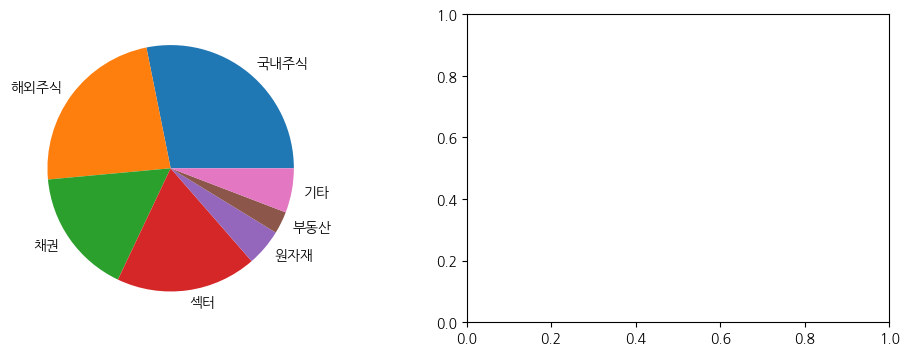

In [34]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4)) # 1행, 2행 및 figsize는 그림 크기
# ax1과 ax2는 2행?

ax1.pie(categories.values(), labels = categories.keys())
# bar 그래프를 눞이고 싶으면 barh
ax2.barh(list(categories.key()), list(categories.values()))
plt.show

## ETF 데이터 탐색

- `pd.DataFrame(list_of_dicts)` — 리스트 형태 ETF 정보를 DataFrame 으로 변환
- `df['cat'].unique()` — 카테고리 종류 추출
- `df[df['cat'] == '국내주식']` — 불린 인덱싱으로 필터링
- 카테고리별 색상을 지정한 위험(risk) - 수익률(ret_1y) 산점도 시각화


In [13]:
etf_universe = [
    {"name": "KODEX 200", "cat": "국내주식", "ret_1y": 12.3, "risk": 15.2},
    {"name": "TIGER S&P500", "cat": "해외주식", "ret_1y": 18.5, "risk": 13.8},
    {"name": "KODEX 배당가치", "cat": "배당", "ret_1y": 8.2, "risk": 10.5},
    {"name": "TIGER 반도체", "cat": "섹터", "ret_1y": 35.2, "risk": 28.4},
    {"name": "KODEX 국고채3년", "cat": "채권", "ret_1y": 3.5, "risk": 2.1},
    {"name": "KODEX 골드선물", "cat": "원자재", "ret_1y": 15.8, "risk": 16.3},
    {"name": "KODEX 2차전지", "cat": "섹터", "ret_1y": -5.2, "risk": 32.1},
    {"name": "TIGER 단기통안채", "cat": "채권", "ret_1y": 3.2, "risk": 0.8},
]

In [14]:
# 산점도..
df_etf = pd.DataFrame(etf_universe)
df_etf

,name,cat,ret_1y,risk
0,KODEX 200,국내주식,12.3,15.2
1,TIGER S&P500,해외주식,18.5,13.8
2,KODEX 배당가치,배당,8.2,10.5
3,TIGER 반도체,섹터,35.2,28.4
4,KODEX 국고채3년,채권,3.5,2.1
5,KODEX 골드선물,원자재,15.8,16.3
6,KODEX 2차전지,섹터,-5.2,32.1
7,TIGER 단기통안채,채권,3.2,0.8


In [21]:
df_etf['cat'], df_etf['cat'].unique()

(0    국내주식
 1    해외주식
 2      배당
 3      섹터
 4      채권
 5     원자재
 6      섹터
 7      채권
 Name: cat, dtype: object,
 array(['국내주식', '해외주식', '배당', '섹터', '채권', '원자재'], dtype=object))

In [25]:
df_etf['cat'] == '국내주식'

,cat
0,True
1,False
2,False
3,False
4,False
5,False
6,False
7,False


In [26]:
# True인 것만 뽑아내려면
df_etf[df_etf['cat'] == '국내주식']

,name,cat,ret_1y,risk
0,KODEX 200,국내주식,12.3,15.2


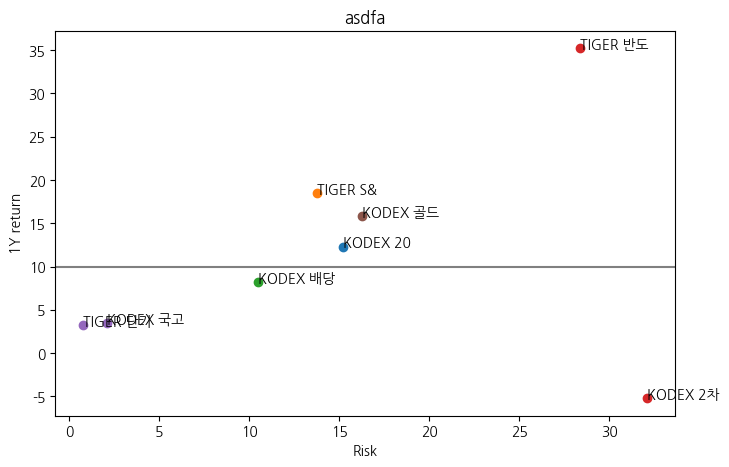

In [35]:
fig, ax = plt.subplots(figsize = (8, 5)) # 하나만 그림 (ax,,)

for cat in df_etf['cat'].unique(): # 카테고리 컬럼명 중에서 중복 제외? -> 카테고리만 뽑아내서 cat 변수에 담았음
  sub = df_etf[df_etf['cat'] == cat]
  ax.scatter(sub['risk'], sub['ret_1y'], label = cat)
  for _, row in sub.iterrows():
    ax.annotate(row['name'][:8], (row['risk'], row['ret_1y']))

# x축 y축 및 타이틀 이름 달기

ax.set_xlabel('Risk')
ax.set_ylabel('1Y return')
ax.set_title('asdfa')
ax.axhline(y=10, color='gray') # 특정 선 긋기

plt.show()

## 데이터 스키마 설계
- 스키마는 쉽게 말해 규칙.
- 통일되지 않은 데이터 정책 또는 네이밍 등은 위험함
  - 예를 들면 "국내주식" vs. "국내 주식"

In [36]:
@dataclass # 데이터와 관련된 클래스라고 명시하는것, __init__ 등이 자동으로 생성되므로 작성할 필요 없음
class ETFSchema:
  # def __init__() 을 왜 안씀?? => @dataclass 로 사용하기 위함 (데코레이터 작성시, 자동으로 내부에서 생성된다고 생각)

  ticker : str # 각각의 필드값이 가져야 하는 데이터 타입을 지정
  name : str
  category : str
  expense_ratio : float
  risk_level : str = "중간" # 디폴트 값
  aum_billion : float = 0.0 # 아마 연간 운영금액?
  description : str = ""
  keywords : List[str] = field(default_factory=list) # List 및 field는 -> 저런 클래스에 해당하는 내용들을 강제해준다 라고 생각

def __post_init__(self): # 유효성 검증하는 함수라고 생각 (dataclass 전용 초기화 후처리 메서드)
  if self.expense_ratio < 0 or self.expense_ratio > 5:
    raise ValueError(f"수수료 범위 오류 : {self.expense_ratio}")
  valid_risks = ["매우낮음", "낮음", "중간", "높음", "매우높음"]
  if self.risk_level not in valid_risks: # self.risk_level이 위의 리스트 요소에 없다면 ValueError를 내라!
    raise ValueError(f"리스크 등급 오류: {self.risk_level}") # "매우 낮음"이라고 스페이스바를 추가하면 오류..



### @dataclass
- @dataclass는 클래스 필드 선언을 기반으로 __init__()을 자동 생성함
- 자동 생성된 __init__()의 마지막 줄에서 __post_init__()을 자동으로 호출하도록 코드가 삽입됨
- 실행 순서는 아래와 같음
```
ETFReturns("SPY", 105.0, 210.0, 330.0, 450.0) 호출
        ↓
@dataclass가 생성한 __init__() 실행
  → self.ticker = "SPY"
  → self.return_1m = 105.0
  → self.return_3m = 210.0  (등등 필드 할당)
        ↓
__post_init__() 자동 호출  ← 여기서 유효성 검사 수행
```
- 객체가 생성될 때 4개의 수익률 값이 모두 100 ≤ value ≤ 500 범위 안에 있는지 자동으로 체크 (정정: 실제 코드에서는 -100 ≤ value ≤ 500 범위로 검증)
- 범위를 벗어나면 ValueError를 즉시 raise해서, 잘못된 상태의 객체가 생성되는 것을 원천 차단
- __post_init__이 없으면 이 검사를 별도로 validate() 같은 메서드를 만들어 수동 호출

### ETFSchema 인스턴스 생성 & 사용

- 키워드 인자로 각 필드를 명시하여 객체 생성
- `.ticker`, `.name`, `.expense_ratio` 등 속성 접근으로 값 확인


In [38]:
etf = ETFSchema(
    ticker = "069500", name = "KODEX 200", category="국내주식", expense_ratio = 1.5, keywords = ['코스피', '대형주','인덱스']
)

In [39]:
etf.ticker, etf.name, etf.expense_ratio

('069500', 'KODEX 200', 1.5)

### JSON 직렬화 / 역직렬화

- `asdict(etf)` — dataclass 인스턴스 → dict
- `json.dumps(dict, ensure_ascii=False, indent=2)` — dict → JSON 문자열 (한글 보존)
- `ETFSchema(**json.loads(json_str))` — JSON 문자열 → dict → dataclass 복원 (`**` 로 언패킹 필수)


In [40]:
etf_dict = asdict(etf) # asdict() -> 데이터 스키마에 정의된 데이터들을 딕셔너리 형태로 만들어줌
                       # asdict()는 파이썬 표준 라이브러리인 dataclasses 모듈에 포함된 함수

In [41]:
etf_dict

{'ticker': '069500',
 'name': 'KODEX 200',
 'category': '국내주식',
 'expense_ratio': 1.5,
 'risk_level': '중간',
 'aum_billion': 0.0,
 'description': '',
 'keywords': ['코스피', '대형주', '인덱스']}

In [43]:
etf_json = json.dumps(etf_dict, ensure_ascii=False, indent = 2)

In [44]:
etf_json

'{\n  "ticker": "069500",\n  "name": "KODEX 200",\n  "category": "국내주식",\n  "expense_ratio": 1.5,\n  "risk_level": "중간",\n  "aum_billion": 0.0,\n  "description": "",\n  "keywords": [\n    "코스피",\n    "대형주",\n    "인덱스"\n  ]\n}'

In [45]:
ETFSchema(json.loads(etf_json)) # json으로 load한 etf_json이 string 형태로 들어가서 오류가 나는것임

TypeError: ETFSchema.__init__() missing 3 required positional arguments: 'name', 'category', and 'expense_ratio'

In [47]:
ETFSchema(**json.loads(etf_json)) # 별표 ** 두개를 넣어주면 복원됨

ETFSchema(ticker='069500', name='KODEX 200', category='국내주식', expense_ratio=1.5, risk_level='중간', aum_billion=0.0, description='', keywords=['코스피', '대형주', '인덱스'])

### 스키마 유효성 검증 테스트

정상 케이스와 필드 누락·타입 불일치 등 비정상 케이스를 반복 실행해 스키마가 올바르게 거르는지 확인.


In [58]:
test_cases = [
    {"name": "KODEX 200", "cat": "국내주식", "ret_1y": 12.3, "risk": 15.2},
    {"name": "TIGER S&P500", "cat": "해외주식", "ret_1y": 18.5, "risk": 13.8},
    {"name": "KODEX 배당가치", "cat": "배당", "ret_1y": 8.2, "risk": 10.5},
    {"name": "TIGER 반도체", "cat": "섹터", "ret_1y": 35.2, "risk": 28.4},
    {"name": "KODEX 국고채3년", "cat": "채권", "ret_1y": 3.5, "risk": 2.1},
    {"name": "KODEX 골드선물", "cat": "원자재", "ret_1y": 15.8, "risk": 16.3},
    {"name": "KODEX 2차전지", "cat": "섹터", "ret_1y": -5.2, "risk": 32.1},
    {"name": "TIGER 단기통안채", "cat": "채권", "ret_1y": 3.2, "risk": 0.8},
]

In [59]:
for tc in test_cases:
  try:
    e = ETFSchema(**tc)
    print(f" {tc['name']}: 생성 성공")
  except ValueError as err:
    print(f" {tc['name']}: {err}")

TypeError: ETFSchema.__init__() got an unexpected keyword argument 'ret_1y'

### ETFReturns — `__post_init__` 로 범위 검증

- 1개월·3개월·1년·3년 수익률 필드를 가진 dataclass
- `__post_init__` 에서 각 값이 **-100% ~ 500%** 범위인지 확인, 벗어나면 `ValueError`
- 원본 코드 주석에 `100%~ 500%` 로 적힌 것은 오탈자 (실제로는 -100 ~ 500)


In [ ]:
# ETFReturns : 데이터 스키마
# __post_initt__ 수익률 유효성 검증 (100%~ 500%)
ticker: str
return_1m
return_3m
return_1y
return_3y

In [65]:
@dataclass
class ETFReturns:
  ticker : str
  return_1m : float
  return_3m : float
  return_1y : float
  return_3y : float

def __post_init__(self):
  # MIN = -100
  # MAX = 500

  # returns = {
  #     "1개월": self.return_1m,
  #     "3개월": self.return_3m,
  #     "1년": self.return_1y,
  #     "3년": self.return_3y
  # }

  # for period, value in returns.items():
  #     if not (MIN <= value <= MAX):
  #         raise ValueError(f"{period} 수익률 범위 오류: {value}%")

  # 강사님 내용
  # if getattr(self, 'return_1m') < -100 or getattr(self, 'return_1m') > 500:
  #   raise ValueError(f"rate 범위 오류: {self.return_1m}")
  for field_name in ['return_1m', 'return_3m', 'return_1y', 'return_3y']:
    value = getattr(self, field_name)
    if value < -100 or value > 500:
      raise ValueError(f"{field_name} 오류: {value}")

In [66]:
ETFReturns("1235", -200.1, 5.4, 12.3, 25.2) # 왜 오류가 안뜨지..

ETFReturns(ticker='1235', return_1m=-200.1, return_3m=5.4, return_1y=12.3, return_3y=25.2)

## FinanceDataReader 로 ETF 데이터 수집

한국 ETF 시장 데이터를 손쉽게 가져오는 라이브러리.

- `fdr.StockListing("ETF/KR")` — 국내 상장 ETF 전체 목록
- `fdr.DataReader(ticker, start, end)` — 특정 종목의 OHLCV 시계열


In [67]:
!pip install finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.3 MB/s eta 0:00:00


In [ ]:
# StockListing('ETF/KR')
# DataReader('1235,,', start, end)

In [69]:
import FinanceDataReader as fdr

In [70]:
etf_list = fdr.StockListing('ETF/KR')

In [71]:
etf_list

,Symbol,Category,Name,Price,RiseFall,Change,ChangeRate,NAV,EarningRate,Volume,Amount,MarCap
0,069500,1,KODEX 200,90430,2,2550,2.90,90560.0,28.4924,14863983,1351020,207537
1,360750,4,TIGER 미국S&P500,25330,2,265,1.06,25291.0,-1.5438,10867442,275477,156881
2,396500,2,TIGER 반도체TOP10,34600,2,850,2.52,34824.0,45.4427,16138341,561843,94994
3,133690,4,TIGER 미국나스닥100,166875,2,2195,1.33,166394.0,-2.0232,694192,115892,84272
4,379800,4,KODEX 미국S&P500,23155,2,250,1.09,23115.0,-1.5748,13222149,306290,82710
...,...,...,...,...,...,...,...,...,...,...,...,...
1083,465620,4,ACE 미국빅테크TOP7 Plus인버스(합성),7090,5,-105,-1.46,7099.0,2.7857,796,5,18
1084,334700,5,RISE 팔라듐선물인버스(H),2925,5,-80,-2.66,2900.0,12.1268,2552,7,18
1085,412560,2,TIGER BBIG레버리지,2400,2,50,2.13,2372.0,-10.8160,9175,21,17
1086,306520,3,HANARO 200선물인버스,3460,5,-105,-2.95,3444.0,-28.9133,2276,7,12


In [73]:
etf_list.head(3)

,Symbol,Category,Name,Price,RiseFall,Change,ChangeRate,NAV,EarningRate,Volume,Amount,MarCap
0,069500,1,KODEX 200,90430,2,2550,2.90,90560.0,28.4924,14863983,1351020,207537
1,360750,4,TIGER 미국S&P500,25330,2,265,1.06,25291.0,-1.5438,10867442,275477,156881
2,396500,2,TIGER 반도체TOP10,34600,2,850,2.52,34824.0,45.4427,16138341,561843,94994


In [81]:
ticker = "069500"
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')

end_date, start_date

('2026-04-14', '2025-04-14')

In [82]:
price_df = fdr.DataReader(ticker, start_date, end_date)

In [83]:
price_df

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-04-14,32343,32570,32271,32373,5621869,0.006342
2025-04-15,32417,32781,32417,32692,8915848,0.009854
2025-04-16,32556,32614,32169,32183,7177604,-0.015570
2025-04-17,32271,32561,32203,32501,6951765,0.009881
2025-04-18,32556,32722,32452,32722,6025639,0.006800
...,...,...,...,...,...,...
2026-04-08,87850,90070,87400,89000,29329013,0.075269
2026-04-09,88310,88735,87070,87250,20553049,-0.019663
2026-04-10,88795,89805,88520,88655,12112242,0.016103


### 수집 함수화 — `collect_etf_price`

- 티커와 `days` (기본 365) 를 받아 해당 기간 OHLCV DataFrame 반환
- 재사용 편의를 위해 날짜 계산을 함수 내부로 캡슐화


In [86]:
# 함수로 묶으면 편하게 가져올 수 있음
def collect_etf_price(ticker, days=365):
  end_date = datetime.now().strftime('%Y-%m-%d')
  start_date = (datetime.now() - timedelta(days=days)).strftime('%Y-%m-%d')

  try:
    df = fdr.DataReader(ticker, start_date, end_date)
    if len(df) > 0:
      return {'status': 'real', 'data' : df, 'ticker':ticker}

  except Exception:
    pass

In [88]:
tickers = ['069500']
collect_etf_price(tickers[0])

{'status': 'real',
 'data':              Open   High    Low  Close    Volume    Change
 Date                                                      
 2025-04-14  32343  32570  32271  32373   5621869  0.006342
 2025-04-15  32417  32781  32417  32692   8915848  0.009854
 2025-04-16  32556  32614  32169  32183   7177604 -0.015570
 2025-04-17  32271  32561  32203  32501   6951765  0.009881
 2025-04-18  32556  32722  32452  32722   6025639  0.006800
 ...           ...    ...    ...    ...       ...       ...
 2026-04-08  87850  90070  87400  89000  29329013  0.075269
 2026-04-09  88310  88735  87070  87250  20553049 -0.019663
 2026-04-10  88795  89805  88520  88655  12112242  0.016103
 2026-04-13  86465  88090  86410  87880  13658534 -0.008742
 2026-04-14  90245  91600  89955  90430  14863983  0.029017
 
 [244 rows x 6 columns],
 'ticker': '069500'}

## 결측치 처리

실전 데이터는 주말·휴일·오류로 결측이 섞여있음. 처리 방식 비교:

| 방법 | 함수 | 특징 |
|---|---|---|
| Forward-fill | `.ffill()` | 직전 값으로 채움, 단순·빠름 |
| 선형 보간 | `.interpolate(method="linear")` | 앞뒤 값의 직선으로 추정, 시계열 자연스러움 |
| Rolling-mean | `.rolling(window).mean()` | 구간 평균으로 대체, 노이즈 완화 |

랜덤 마스크로 `Close` 일부를 `NaN` 으로 만든 뒤 세 방식의 결과를 시각화하여 비교.


In [ ]:
# 결측치, 이상치 처리 => 데이터 분석
  # 결측치? 주말, 휴장일, 선거일 등등 -> row 전체가 결측치
  # row 중의 하나(일부)의 속성만 비어있는 경우

# 결측치 처리 방법
  # 무시: 결측치 있는 값을 지워버림
  # 채움:
    # 1. 전/후의 값을 interpolation (평균) 하거나
    # 2. 이전, 이후의 값을 그대로 채움
    # 3. rolling-average 활용
    # 또는 step이 일정하도록(잔차가 일정하도록) 채워줌 예 : 1000 X X 4000일 경우 1000, (2000), (3000), 4000 등

# 이상치 처리 (outlier, anomaly)
  # IQR: anomary detect -> 결측치를 지워버리거나, 채워줌

In [89]:
sample_df = price_df.copy() # copy()하지 않고 그대로 넣게되면 참조값도 함께 넘겨주기 때문에, 인자로 넣은 객체를 변경하면 원본도 변경됨

In [94]:
np.random.random(5)

array([0.71189466, 0.44035572, 0.17267198, 0.01463022, 0.19757313])

In [93]:
mask = np.random.random(len(sample_df)) < 0.05
mask

array([False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [95]:
sample_df.loc[mask, 'Close'] = np.nan # mask 가 True인 값들 중(즉, 랜덤한 마스크 위치)에서 속성이 'Close'인 것들을 nan을 부여함

In [98]:
sample_df['Close'].isna().sum() # 10개가 지워짐

np.int64(10)

In [99]:
ffill_df = sample_df.copy() # forward fill
ffill_df['Close'] = ffill_df['Close'].ffill()

In [100]:
ffill_df['Close'].isna().sum() # 이러면 결측치가 없는것을 볼수있음

np.int64(0)

np.int64(0)

In [101]:
interp_df = sample_df.copy()
interp_df['Close'].isna().sum()

np.int64(10)

In [102]:
interp_df['Close'] = interp_df['Close'].interpolate(method='linear')

In [106]:
# Rolling-average

rolling_df = sample_df.copy()
rolling_mean = rolling_df['Close'].rolling(5, min_periods=1).mean() # 해당 일자의 5개를 이용해 이동평균 구함
rolling_mean
rolling_df['Close'] = rolling_df['Close'].fillna(rolling_mean) # na 값들만 rolling_mean으로 채워라

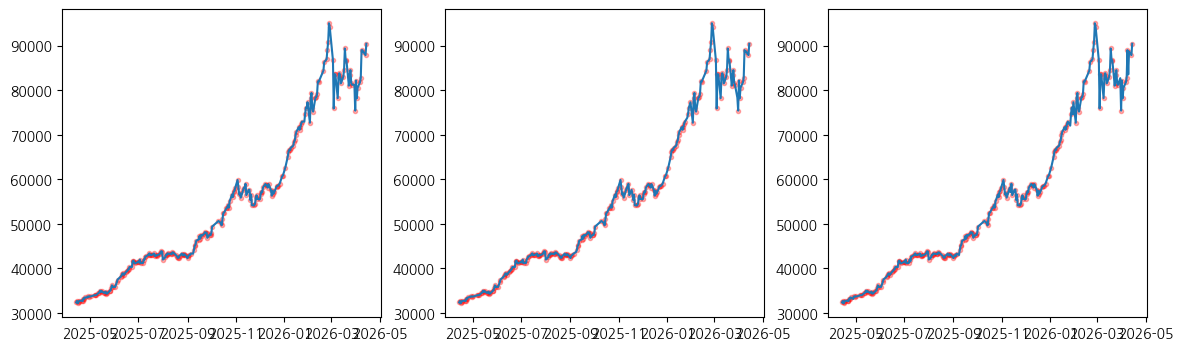

In [110]:
fig, axes = plt.subplots(1, 3, figsize = (14,4))
for ax, df_filled, title in zip(axes, [ffill_df, interp_df, rolling_df], ['Forward fill', 'Interpol', 'Roll']):
  ax.plot(sample_df.index, sample_df['Close'], 'ro', markersize=3, alpha=0.3, label='missing')
  ax.plot(df_filled.index, df_filled['Close'], label=title)

### 이상치 탐지 (IQR · Z-score)

정상 분포에서 벗어난 값을 탐지하여 분석 신뢰도를 확보.

| 방식 | 기준 | 특징 |
|---|---|---|
| IQR | Q1 - 1.5·IQR ~ Q3 + 1.5·IQR 벗어난 값 | 분포 가정 없음, 금융 데이터에 적합 |
| Z-score | 평균에서 ±3σ 벗어난 값 | 정규분포 가정, 간단 |

- `detect_iqr(series, factor=1.5)`: IQR 방식 이상치 마스크 반환
- `detect_z(series, threshold=3.0)`: Z-score 방식 이상치 마스크 반환
- 두 방식을 `&` / `|` 로 결합해 교집합·합집합 탐지 가능

_(원문 제목: `#### 이상치탐지 (IQR)` 을 `### 이상치 탐지 (IQR · Z-score)` 로 정리)_

In [114]:
def detect_iqr(series, factor=1.5): # 상위 n%의 몇배를 이상치로 볼것인지 (factor=1.5 -> 1.5배)
  q1, q3 = series.quantile(0.25), series.quantile(0.75)
  iqr = q3 - q1
  return (series < q1 - factor * iqr) | (series > q3 + factor * iqr)

# z = (1000 - 평균) / 표준편차

def detect_z(series, threshold = 3.0):
  z = (series - series.mean()) / series.std()
  return z.abs() > threshold


z_outliers = detect_z(ffill_df)
z_outliers.sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,3
Change,7


In [116]:
iqr_outliers = detect_iqr(ffill_df)
iqr_outliers.sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,10
Change,23


In [117]:
(z_outliers & iqr_outliers).sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,3
Change,7


In [111]:
type(sample_df['Close'])

pandas.core.series.Series

In [118]:
ffill_df.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-04-14,32343,32570,32271,32373.0,5621869,0.006342
2025-04-15,32417,32781,32417,32692.0,8915848,0.009854
2025-04-16,32556,32614,32169,32183.0,7177604,-0.015570
2025-04-17,32271,32561,32203,32501.0,6951765,0.009881
2025-04-18,32556,32722,32452,32722.0,6025639,0.006800


## 특성 추출

Close 가격으로부터 모델이 사용할 피처를 파생.

- `return = Close.pct_change()` — 일별 단순수익률
- `vol_5d`, `vol_20d` — 5일·20일 rolling 표준편차 (변동성)
- `log_return = log(Close_t / Close_{t-1})` — 로그수익률 (시계열 정상성·가산성 확보)


In [119]:
features = ffill_df[['Close']].copy()

In [120]:
features

,Close
Date,
2025-04-14,32373.0
2025-04-15,32692.0
2025-04-16,32183.0
2025-04-17,32501.0
2025-04-18,32722.0
...,...
2026-04-08,89000.0
2026-04-09,89000.0
2026-04-10,88655.0


In [121]:
features['return'] = features['Close'].pct_change()

In [124]:
features.head() # 첫번째 값은 이전 대비 얼마나 변했는지 모르므로 NaN임

,Close,return
Date,,
2025-04-14,32373.0,NaN
2025-04-15,32692.0,0.009854
2025-04-16,32183.0,-0.015570
2025-04-17,32501.0,0.009881
2025-04-18,32722.0,0.006800


In [133]:
features['vol_5d'] = features['return'].rolling(5).std() # 5일 변동성
features['vol_20d'] = features['return'].rolling(20).std() # 20일 변동성

In [134]:
features.head()

,Close,return,vol_5d,vol_20d
Date,,,,
2025-04-14,32373.0,NaN,NaN,NaN
2025-04-15,32692.0,0.009854,NaN,NaN
2025-04-16,32183.0,-0.015570,NaN,NaN
2025-04-17,32501.0,0.009881,NaN,NaN
2025-04-18,32722.0,0.006800,NaN,NaN


In [136]:
features.head(15) # 5일 이후에는 평균값 확인가능, 20일도 마찬가지

,Close,return,vol_5d,vol_20d
Date,,,,
2025-04-14,32373.0,NaN,NaN,NaN
2025-04-15,32692.0,0.009854,NaN,NaN
2025-04-16,32183.0,-0.015570,NaN,NaN
2025-04-17,32501.0,0.009881,NaN,NaN
2025-04-18,32722.0,0.006800,NaN,NaN
2025-04-21,32766.0,0.001345,0.010664,NaN
2025-04-22,32658.0,-0.003296,0.009985,NaN
2025-04-23,33247.0,0.018035,0.008172,NaN
2025-04-24,33188.0,-0.001775,0.008634,NaN


In [137]:
features['log_return'] = np.log(features['Close']/ features['Close'].shift(1))

## 전처리 파이프라인

결측치 보간 → 이상치 처리 → 특성 추가 일련의 단계를 하나의 함수 `preprocess_pipeline(df)` 로 묶음.

- 1단계: `interpolate(method="linear")` — 선형보간으로 결측치 처리
- 2단계: IQR 기반 이상치 탐지 (forward-fill 대체)
- 3단계: 특성 추가 (`return`, `log_return`)


In [141]:
missing_df = sample_df.copy()
missing_df.isna().sum()

,0
Open,0
High,0
Low,0
Close,10
Volume,0
Change,0


In [ ]:
# def preprocess_pipeline(df):

#   # 1. 결측값 처리 (선형보간)
#   df['Close'] = df['Close'].interpolate(method='linear')

#   # 2. 이상치를 ffill로 채움 (IQR)
#   def _detect_iqr(series, factor=1.5): # 상위 n%의 몇배를 이상치로 볼것인지 (factor=1.5 -> 1.5배)
#     q1, q3 = series.quantile(0.25), series.quantile(0.75)
#     iqr = q3 - q1
#     return (series < q1 - factor * iqr) | (series > q3 + factor * iqr)

#   def _detect_z(series, threshold = 3.0):
#     z = (series - series.mean()) / series.std()
#     return z.abs() > threshold

#   z_outliers = _detect_z(df)
#   iqr_outliers = _detect_iqr(df)

#   # 3. feature 추가 (return, log_return)
#   df['return'] = df['Close'].pct_change()
#   df['log_return'] = np.log(df['Close']/ df['Close'].shift(1))

#   result = df.copy()

#   return result

In [143]:
def preprocess_pipeline(df):
  result = df[['Close']].copy()

# 1. 결측값 처리 (선형보간)
  result['Close'] = result['Close'].interpolate(method = 'linear')
  result['Close'] = result['Close'].ffill().bfill()

# 2. 이상치를 ffill로 채움 (IQR)
  ret = result['Close']
  q1, q3 = ret.quantile(0.25), ret.quantile(0.75)
  iqr = q3 - q1

  outlier_mask = (ret < q1 - 1.5 * iqr) | (ret > q3 + 1.5 * iqr)
  result.loc[outlier_mask, 'Close'] = np.nan
  result['Close'] = result['Close'].ffill()

  # 3. feature 추가
  result['return'] = result['Close'].pct_change()
  result['log_return'] = np.log(result['Close']/ result['Close'].shift(1))

  return result

In [144]:
processed = preprocess_pipeline(price_df)

In [145]:
processed.head()

,Close,return,log_return
Date,,,
2025-04-14,32373.0,NaN,NaN
2025-04-15,32692.0,0.009854,0.009806
2025-04-16,32183.0,-0.015570,-0.015692
2025-04-17,32501.0,0.009881,0.009832
2025-04-18,32722.0,0.006800,0.006777


In [ ]:
# 이동 평균, 트렌드 분해(decomposition), 이상 탐지, 분포 분석

# 1. 이동평균
  # 서버 트래픽, 이커머스 구매내역, 센서 데이터, 온도 등등
  # 이동평균 사용하는 이유: 노이즈
  # S(standard)MA : 최근 N개의 평균
  # E(exponential)MA : 최근 값에 더 큰 가중치를 두는 MA (웹 트래픽, 트렌드 등)


# 2. 트렌드 분해
  # 시계열 데이터에는
  # 트렌드 : 장기적으로 매출이 상승/하락. 전반적으로 연령별 타겟 시장이 커진다 등
  # Seasonality (계절성, 주기 등): 여름에 잘팔리고 겨울에는 안팔리는 등..
  # Residual (잔차) : 나머지 (트렌드 및 Seasonality로 표현되지 않는 나머지 부분)